In [110]:
%reset -f
%reload_ext autoreload
%autoreload 2

In [111]:
import os,sys
current_path = os.getcwd()

In [ ]:
name = current_path.split('/')[-1].split('_')
data = name[0]
cust = name[1]

sys.path.append("/home/zhuchen/poc/02-xyf2/config") 
sys.path.append("/home/zhuchen/poc/scorecard") 
FILE_PATH = f'/home/zhuchen/poc/02-xyf2/{data}_{cust}/file/'
DATA_PATH = f'/home/zhuchen/poc/02-xyf2/{data}_{cust}/data/'
TMP_PATH  = f'/home/zhuchen/poc/02-xyf2/{data}_{cust}/tmp/'
DATA_OR_PATH = '/home/zhuchen/poc/02-xyf2/data_or/'

In [113]:
print(name)

['ronghe', 'all']


In [ ]:
name1 = 'deltaV1'+'_'+cust
name2 = 'thetaV2'+'_'+cust
name3 = 'zetaV2'+'_'+cust


DATA_PATH_name1 = f'/home/zhuchen/poc/02-xyf2/{name1}/data/'
DATA_PATH_name2 = f'/home/zhuchen/poc/02-xyf2/{name2}/data/'
DATA_PATH_name3 = f'/home/zhuchen/poc/02-xyf2/{name3}/data/'

best_flag_path = f'/home/zhuchen/poc/02-xyf2/{name2}/file/'

In [115]:
import pandas as pd 
import numpy as np  
import math  
import matplotlib.pyplot as plt
import copy
import seaborn as sns
import temp_config 

isExists=os.path.exists(FILE_PATH)
if not isExists:
    os.makedirs(FILE_PATH) 
    
isExists=os.path.exists(DATA_PATH)
if not isExists:
    os.makedirs(DATA_PATH) 

isExists=os.path.exists(TMP_PATH)
if not isExists:
    os.makedirs(TMP_PATH) 

import warnings
warnings.filterwarnings("ignore")

In [141]:
# config cell
epoch = temp_config.ronghe_epoch
optuna_index = temp_config.optuna_index
# split_flag = 2025
split_flag = pd.read_csv(best_flag_path + 'best_flag.csv')['best_flag'].tolist()[0]

In [117]:
data_name1 = pd.read_csv(DATA_PATH_name1 + '打分文件.csv', usecols=['mobile', 'backPointTime', 'proba','label','qudao3_act'])
data_name1.rename(columns={'proba':'delta_proba'}, inplace=True)
# data_name1 = data_name1.drop_duplicates(subset=['mobile', 'backPointTime','qudao3_act'], keep='first')
data_name1.reset_index(drop=True, inplace=True)
data_name1

,mobile,backPointTime,qudao3_act,label,delta_proba
0,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.0,0.672212
1,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.0,0.672212
2,f3f4e2f3c61d8f1a035a0c32987714a5,2025-02-21,API,0.0,0.673433
3,6d09e74a845b0c12e86be848d40f4fd3,2025-06-09,API,0.0,0.543671
4,70a24bd8e0cfa4efb16a5a26b3054bc5,2025-04-28,API,0.0,0.634136
...,...,...,...,...,...
1277737,a18e8ccd88bb61bc7f9dd825d25b8850,2024-11-13,APP自然流量,0.0,0.605321
1277738,e0c1b14d5f5953670ed63c102f3ead9f,2024-11-15,APP自然流量,0.0,0.600075
1277739,82bc32734d6acd2f8993add147648f26,2024-11-12,APP自然流量,0.0,0.560857
1277740,45ed4aab69e0a3039def1ed484e79716,2024-11-23,APP自然流量,0.0,0.675885


In [118]:
data_name2 = pd.read_csv(DATA_PATH_name2 + '打分文件.csv',usecols=['mobile', 'backPointTime', 'proba','qudao3_act'])
data_name2.rename(columns={'proba':'theta_proba'}, inplace=True)
data_name2 = data_name2.drop_duplicates(subset=['mobile', 'backPointTime','qudao3_act'], keep='first')
data_name2.reset_index(drop=True, inplace=True)
data_name2

,mobile,backPointTime,qudao3_act,theta_proba
0,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.084997
1,f3f4e2f3c61d8f1a035a0c32987714a5,2025-02-21,API,0.047374
2,6d09e74a845b0c12e86be848d40f4fd3,2025-06-09,API,0.050627
3,70a24bd8e0cfa4efb16a5a26b3054bc5,2025-04-28,API,0.069634
4,7c9b40cbe1ef565aa464ccdb721f47f6,2024-12-24,API,0.043136
...,...,...,...,...
1277535,a18e8ccd88bb61bc7f9dd825d25b8850,2024-11-13,APP自然流量,0.050161
1277536,e0c1b14d5f5953670ed63c102f3ead9f,2024-11-15,APP自然流量,0.036826
1277537,82bc32734d6acd2f8993add147648f26,2024-11-12,APP自然流量,0.035074
1277538,45ed4aab69e0a3039def1ed484e79716,2024-11-23,APP自然流量,0.043143


In [119]:
data_name3 = pd.read_csv(DATA_PATH_name3 + '打分文件.csv',usecols=['mobile', 'backPointTime', 'proba','qudao3_act'])
data_name3.rename(columns={'proba':'zeta_proba'}, inplace=True)
data_name3 = data_name3.drop_duplicates(subset=['mobile', 'backPointTime','qudao3_act'], keep='first')
data_name3.reset_index(drop=True, inplace=True)
data_name3

,mobile,backPointTime,qudao3_act,zeta_proba
0,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.309962
1,f3f4e2f3c61d8f1a035a0c32987714a5,2025-02-21,API,0.426941
2,6d09e74a845b0c12e86be848d40f4fd3,2025-06-09,API,0.309962
3,70a24bd8e0cfa4efb16a5a26b3054bc5,2025-04-28,API,0.362761
4,7c9b40cbe1ef565aa464ccdb721f47f6,2024-12-24,API,0.309962
...,...,...,...,...
1277535,a18e8ccd88bb61bc7f9dd825d25b8850,2024-11-13,APP自然流量,0.309962
1277536,e0c1b14d5f5953670ed63c102f3ead9f,2024-11-15,APP自然流量,0.309962
1277537,82bc32734d6acd2f8993add147648f26,2024-11-12,APP自然流量,0.288929
1277538,45ed4aab69e0a3039def1ed484e79716,2024-11-23,APP自然流量,0.411715


In [120]:
data_all = pd.merge( data_name1, data_name2, on=['mobile', 'backPointTime','qudao3_act'], how = 'left')
data_all.reset_index(drop=True, inplace=True)
data_all = pd.merge( data_all, data_name3, on=['mobile', 'backPointTime','qudao3_act'], how = 'left')
data_all.reset_index(drop=True, inplace=True)
data_all['target'] = 'train'
data_all

,mobile,backPointTime,qudao3_act,label,delta_proba,theta_proba,zeta_proba,target
0,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.0,0.672212,0.084997,0.309962,train
1,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.0,0.672212,0.084997,0.309962,train
2,f3f4e2f3c61d8f1a035a0c32987714a5,2025-02-21,API,0.0,0.673433,0.047374,0.426941,train
3,6d09e74a845b0c12e86be848d40f4fd3,2025-06-09,API,0.0,0.543671,0.050627,0.309962,train
4,70a24bd8e0cfa4efb16a5a26b3054bc5,2025-04-28,API,0.0,0.634136,0.069634,0.362761,train
...,...,...,...,...,...,...,...,...
1277737,a18e8ccd88bb61bc7f9dd825d25b8850,2024-11-13,APP自然流量,0.0,0.605321,0.050161,0.309962,train
1277738,e0c1b14d5f5953670ed63c102f3ead9f,2024-11-15,APP自然流量,0.0,0.600075,0.036826,0.309962,train
1277739,82bc32734d6acd2f8993add147648f26,2024-11-12,APP自然流量,0.0,0.560857,0.035074,0.288929,train
1277740,45ed4aab69e0a3039def1ed484e79716,2024-11-23,APP自然流量,0.0,0.675885,0.043143,0.411715,train


In [121]:
data_all[['delta_proba', 'theta_proba','zeta_proba']].corr()

,delta_proba,theta_proba,zeta_proba
delta_proba,1.000000,0.3344,0.022279
theta_proba,0.334400,1.0000,-0.029600
zeta_proba,0.022279,-0.0296,1.000000


### 划分数据集

In [122]:
from DataPreprocessing.Datasets.Describe import badrate_by_month

month_time = badrate_by_month(data_all, 'backPointTime', ['train'], 'label')
month_time

,count,bad,good,bad_rate
2024-07,101890,3192.0,98698.0,0.031328
2024-08,111257,4113.0,107144.0,0.036968
2024-09,116716,4736.0,111980.0,0.040577
2024-10,113623,5003.0,108620.0,0.044032
2024-11,105345,4880.0,100465.0,0.046324
2024-12,107385,4970.0,102415.0,0.046282
2025-01,120569,5661.0,114908.0,0.046952
2025-02,103627,5473.0,98154.0,0.052814
2025-03,114568,6419.0,108149.0,0.056028
2025-04,109790,6019.0,103771.0,0.054823


In [123]:
# 最后10%为oot
data_all.loc[(pd.to_datetime(data_all['backPointTime']) >= pd.to_datetime(data_all['backPointTime']).quantile(0.9)) & (data_all['target'] =='train'),'target'] = 'oot' 

In [124]:
data_all['target'].value_counts()

train    1148251
oot       129491
Name: target, dtype: int64

In [125]:
from DataPreprocessing.Datasets.Split import by_stratify
data_all, res = by_stratify(data_all.fillna(-999), 0.3, split_flag, date='backPointTime', dep='label')

         count  bad_rate      bad    time_min    time_max
all    1277742  0.046695  59664.0  2024-07-01  2025-06-22
train   803775  0.046010  36982.0  2024-07-01  2025-05-10
valid   344476  0.046009  15849.0  2024-07-01  2025-05-10
oot     129491  0.052768   6833.0  2025-05-11  2025-06-22
ratio_bad_good:  0.04822944393076097
train    803775
valid    344476
oot      129491
Name: target, dtype: int64


In [129]:
data_all['weight'] =1
ex_lst = ['mobile', 'label', 'backPointTime', 'target', 'month_time', 'weight','qudao3_act']

ft_lst = [i for i in data_all.columns if i not in ex_lst]
print('num_feature: ', len(ft_lst))
print('data_shape: ', data_all.shape)
ft_lst

num_feature:  3
data_shape:  (1277742, 10)


['delta_proba', 'theta_proba', 'zeta_proba']

In [130]:
import sys
sys.version

'3.8.19 | packaged by conda-forge | (default, Mar 20 2024, 12:47:35) \n[GCC 12.3.0]'

In [131]:
from ScoreCard.creat_report import Report

for i in range(0,(len(ft_lst) // 1000) + 1):
    start, end = i * 1000, min((i + 1) * 1000, len(ft_lst))
    print(start, ' - ', end)
    report = Report(data_all[ft_lst[start:end] + ex_lst], ex_lst, 'label', FILE_PATH + str(i) + '_')
    key_value, bins_detail = report.iv_ks_psi_chi2_missing_quantile()

0  -  3
正在计算IV......
正在计算CHI2......
正在计算COVER RATE......
正在计算QUANTILE......
正在保存结果......
已保存


In [132]:
import os
files_key_value, files_bins_detail = [], []
for root, dirs, files in os.walk(FILE_PATH[:-1]): 
    for file in files:
        if '_bins_detail' in file:
            files_bins_detail.append(pd.read_excel(root +'/'+ file))
        elif 'iv_ipt_psi_chi2_missing' in file:
            files_key_value.append(pd.read_excel(root +'/'+ file))
            
key_value = pd.concat(files_key_value)
bins_detail = pd.concat(files_bins_detail)

bins_detail.to_excel(FILE_PATH + 'bins_detail.xlsx')
key_value.to_excel(FILE_PATH + 'key_value.xlsx')

In [133]:
key_value.sort_values(by='iv_bin_train', ascending=False)

,Unnamed: 0,var_names,ks,iv_bin_train,iv_bin_valid,iv_bin_oot,iv_bin_total,psi_tv_bin,psi_to_bin,psi_tvo_bin,...,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99,max
0,0,theta_proba,0.108682,0.083105,0.062875,0.045467,0.072822,0.000008,0.004258,0.004187,...,0.046904,0.050304,0.053550,0.056737,0.059971,0.063614,0.068508,0.071960,0.080596,0.154753
1,1,zeta_proba,0.087341,0.060359,0.059403,0.029909,0.055901,0.000028,0.012922,0.012790,...,0.309962,0.309962,0.309962,0.309962,0.322140,0.345070,0.394141,0.438896,0.516512,0.671077
2,2,delta_proba,0.084401,0.058861,0.058981,0.023990,0.052383,0.000002,0.020077,0.020169,...,0.630289,0.646937,0.672212,0.675885,0.675885,0.676988,0.687818,0.696944,0.750563,0.861041


In [134]:
data_all.fillna(-999).to_csv(DATA_PATH + 'data_ft_2.csv', index=False, encoding='utf-8-sig')

In [135]:
from DataPreprocessing.Datasets.Split import by_stratify
data_all, res = by_stratify(data_all.fillna(-999), 0.3, split_flag, date='backPointTime', dep='label')

         count  bad_rate      bad    time_min    time_max
all    1277742  0.046695  59664.0  2024-07-01  2025-06-22
train   803775  0.046010  36982.0  2024-07-01  2025-05-10
valid   344476  0.046009  15849.0  2024-07-01  2025-05-10
oot     129491  0.052768   6833.0  2025-05-11  2025-06-22
ratio_bad_good:  0.04822944393076097
train    803775
valid    344476
oot      129491
Name: target, dtype: int64


num_features:  3
逻辑回归：
  datasets       auc  precision    recall        ks        f2        th  \
0    train  0.613047   0.061317  0.605916  0.159693  0.218242  0.492441   
0    valid  0.609982   0.061705  0.575809  0.153699  0.215956  0.497351   
0      oot  0.575663   0.058239  0.805795  0.108979  0.225891  0.429186   

      ratio   count  
0  0.454663  803775  
0  0.429339  344476  
0  0.730097  129491  
  datasets       auc        ks  precision    recall        f2        th  \
0    train  0.613047  0.159693   0.061317  0.605916  0.218242  0.492441   
0    valid  0.609982  0.153699   0.061705  0.575809  0.215956  0.497351   
0      oot  0.575663  0.108979   0.058239  0.805795  0.225891  0.429186   

      ratio   count  
0  0.454663  803775  
0  0.429339  344476  
0  0.730097  129491  


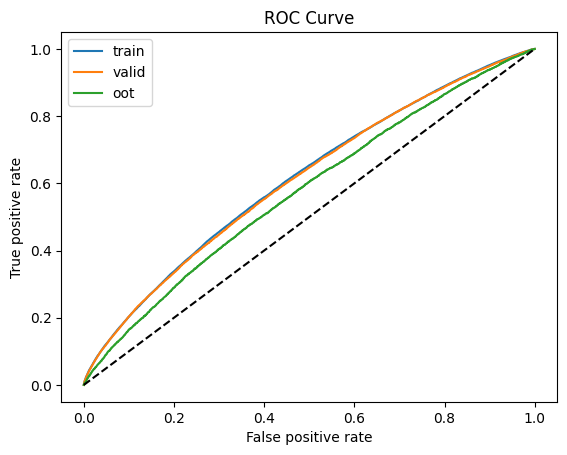

XGBoost：
  datasets       auc  precision    recall        ks        f2        th  \
0    train  0.617299   0.062295  0.596425  0.164140  0.219690  0.044055   
0    valid  0.610263   0.061903  0.574547  0.154872  0.216297  0.044691   
0      oot  0.580525   0.057489  0.867262  0.114759  0.227201  0.031543   

      ratio   count  
0  0.440514  803775  
0  0.427028  344476  
0  0.796048  129491  
  datasets       auc        ks  precision    recall        f2        th  \
0    train  0.617299  0.164140   0.062295  0.596425  0.219690  0.044055   
0    valid  0.610263  0.154872   0.061903  0.574547  0.216297  0.044691   
0      oot  0.580525  0.114759   0.057489  0.867262  0.227201  0.031543   

      ratio   count  
0  0.440514  803775  
0  0.427028  344476  
0  0.796048  129491  


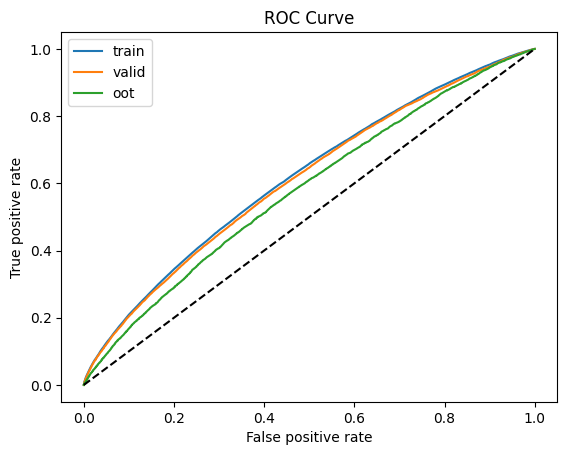

LightGBM：
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
  datasets       auc  precision    recall        ks        f2        th  \
0    train  0.617306   0.062544  0.591801  0.164504  0.219801  0.044528   
0    valid  0.610130   0.058228  0.671020  0.153774  0.216123  0.041589   
0      oot  0.578941   0.057513  0.861262  0.113231  0.226946  0.032745   

      ratio   count  
0  0.435358  803775  
0  0.530208  344476  
0  0.790202  129491  
  datasets       auc        ks  precision    recall        f2        th  \
0    train  0.617306  0.164504   0.062544  0.591801  0.219801  0.044528   
0    valid  0.610130  0.153774   0.058228  0.671020  0.216123  0.041589   
0      oot  0.578941  0.113231   0.057513  0.861262  0.226946  0.032745   

      ratio   count  
0  0.435358  803775  
0  0.530208  344476  


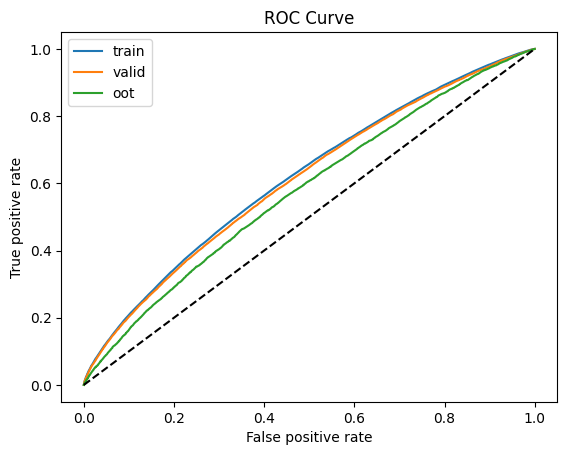

In [136]:
from Model.train import bi_train
res =  bi_train(data_all, dep='label', exclude=ex_lst, model_switch=[1, 1, 1, 0])

In [142]:
keep_lst = ft_lst
data_end = data_all[keep_lst + ex_lst].copy()
len(keep_lst)

3

In [ ]:
from ParameterRegulation.Optuna import run, objective_fix_sample
file_path = FILE_PATH + 'optuna_xgb.xlsx'
print('epoch = ',epoch)
res_opt = run(objective_fix_sample, data_end, ex_lst,  1348, file_path, epoch, 'xgb',max_depth=2)

[I 2025-11-17 10:29:55,017] A new study created in memory with name: no-name-65e1658b-f20a-4146-a1b9-ace13de8b3b7


epoch =  10


[I 2025-11-17 10:29:57,423] Trial 0 finished with value: -0.05601624721720849 and parameters: {'reg_lambda': 0.009533207353672798, 'reg_alpha': 0.4006054428136569, 'n_estimators': 34, 'max_depth': 2, 'min_child_weight': 1, 'learning_rate': 0.25903115389856646, 'col_sample_bytree': 0.11657398774839992, 'scale_pos_weight': 2.1908316471945546, 'gamma': 5.172692307902582e-05, 'subsample': 0.6313668514217989}. Best is trial 0 with value: -0.05601624721720849.
[I 2025-11-17 10:30:00,106] Trial 1 finished with value: -0.05894606400604985 and parameters: {'reg_lambda': 1.092678695221338e-07, 'reg_alpha': 2.2102626692993785e-07, 'n_estimators': 51, 'max_depth': 2, 'min_child_weight': 16, 'learning_rate': 0.21885899724475222, 'col_sample_bytree': 0.5337814646024472, 'scale_pos_weight': 43.64033892904723, 'gamma': 1.0887488704209634e-06, 'subsample': 0.9886099556629396}. Best is trial 0 with value: -0.05601624721720849.
[I 2025-11-17 10:30:02,608] Trial 2 finished with value: -0.05436287013349922

FrozenTrial(number=5, state=TrialState.COMPLETE, values=[-0.051310298939015564], datetime_start=datetime.datetime(2025, 11, 17, 10, 30, 7, 839775), datetime_complete=datetime.datetime(2025, 11, 17, 10, 30, 10, 919937), params={'reg_lambda': 1.9604801006513278e-08, 'reg_alpha': 8.919411143884439e-07, 'n_estimators': 83, 'max_depth': 1, 'min_child_weight': 1, 'learning_rate': 0.032097949759649226, 'col_sample_bytree': 0.1921803449935337, 'scale_pos_weight': 1.7783212740673782, 'gamma': 0.09353080432081107, 'subsample': 0.6186892665954489}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'reg_lambda': FloatDistribution(high=500.0, log=True, low=1e-08, step=None), 'reg_alpha': FloatDistribution(high=1.0, log=True, low=1e-08, step=None), 'n_estimators': IntDistribution(high=100, log=True, low=30, step=1), 'max_depth': IntDistribution(high=2, log=False, low=1, step=1), 'min_child_weight': IntDistribution(high=50, log=True, low=1, step=1), 'learning_rate': FloatDistribu

In [144]:
ress_xgb = pd.read_excel(FILE_PATH + 'optuna_xgb.xlsx')
if 'oot_ks' in ress_xgb.columns:
    res = ress_xgb[ress_xgb['valid_ks'] > 0.1][['train_ks', 'valid_ks', 'oot_ks', 'oot_if_badrate_mono']]
    res = res[res['train_ks'] > 0.1]
    res = res[res['oot_ks'] > 0.1]
    res['delta'] = res['train_ks'] - res['oot_ks']
    res['delta1'] = res['valid_ks'] - res['oot_ks']
    res['delta2'] = res['valid_ks'] - res['train_ks']
    #res = res[abs(res['delta']) < 0.03]
    #res = res[abs(res['delta1']) < 0.03]
    #res = res[abs(res['delta2']) < 0.03]
    #res = res[res['oot_if_badrate_mono']==1]
    res.sort_values(by='oot_ks', ascending=False, inplace=True)
else:
    res = ress_xgb[ress_xgb['valid_ks'] > 0.27][['train_ks', 'valid_ks']]
    res = res[res['train_ks'] > 0.27]
    res['delta2'] = res['valid_ks'] - res['train_ks']
    res = res[abs(res['delta2']) < 0.03]
    res.sort_values(by='oot_ks', ascending=False, inplace=True)
res_xgb = res.copy()
res_xgb

,train_ks,valid_ks,oot_ks,oot_if_badrate_mono,delta,delta1,delta2
1,0.163810,0.154257,0.114416,True,0.049394,0.039841,-0.009553
3,0.163424,0.154636,0.114379,True,0.049045,0.040258,-0.008788
9,0.160895,0.152091,0.113304,False,0.047591,0.038787,-0.008804
4,0.159406,0.152392,0.113297,False,0.046109,0.039095,-0.007014
0,0.162225,0.155350,0.113083,False,0.049141,0.042266,-0.006875
2,0.154018,0.145138,0.108534,False,0.045484,0.036604,-0.008879
6,0.155186,0.148156,0.107950,False,0.047236,0.040206,-0.007030
5,0.152935,0.146957,0.107603,True,0.045332,0.039354,-0.005978
8,0.150843,0.141679,0.103646,False,0.047197,0.038033,-0.009164
7,0.146880,0.138064,0.101632,False,0.045248,0.036432,-0.008817


In [146]:
res_xgb.to_csv(DATA_PATH + 'res_model_xgb.csv')

In [147]:
FILE_PATH

'/home/zhuchen/poc/02-xyf/ronghe_all/file/'

In [148]:
params = eval(ress_xgb.iloc[res_xgb.index[optuna_index]]['model_param'])
params

{'verbosity': 0,
 'booster': 'gbtree',
 'reg_lambda': 1.092678695221338e-07,
 'reg_alpha': 2.2102626692993785e-07,
 'n_estimators': 51,
 'max_depth': 2,
 'min_child_weight': 16,
 'learning_rate': 0.21885899724475222,
 'col_sample_bytree': 0.5337814646024472,
 'scale_pos_weight': 43.64033892904723,
 'gamma': 1.0887488704209634e-06,
 'subsample': 0.9886099556629396}

In [149]:
from Model.train import show
import xgboost as xgb
nan = np.nan



print('num_features: ', len(keep_lst))
model = xgb.XGBClassifier(**params)

model.fit(data_end[data_end['target'] == 'train'][keep_lst], 
          data_end[data_end['target'] == 'train']['label'], 
          sample_weight=data_end[data_end['target'] == 'train']['weight'])

import joblib
#lr是一个LogisticRegression模型
joblib.dump(model, 'model.model')
model = joblib.load('model.model')
pd.DataFrame({'var_names':keep_lst}).to_csv('keep_lst.csv', index=False)

num_features:  3


  datasets       auc  precision    recall        ks        f2        th  \
0    train  0.617015   0.060923  0.628955  0.163810  0.219550  0.662598   
0    valid  0.610083   0.060680  0.604644  0.154257  0.216492  0.664715   
0      oot  0.579171   0.058722  0.803747  0.114416  0.227210  0.612238   

      ratio   count  
0  0.474997  803775  
0  0.458459  344476  
0  0.722251  129491  
  datasets       auc        ks  precision    recall        f2        th  \
0    train  0.617015  0.163810   0.060923  0.628955  0.219550  0.662598   
0    valid  0.610083  0.154257   0.060680  0.604644  0.216492  0.664715   
0      oot  0.579171  0.114416   0.058722  0.803747  0.227210  0.612238   

      ratio   count  
0  0.474997  803775  
0  0.458459  344476  
0  0.722251  129491  


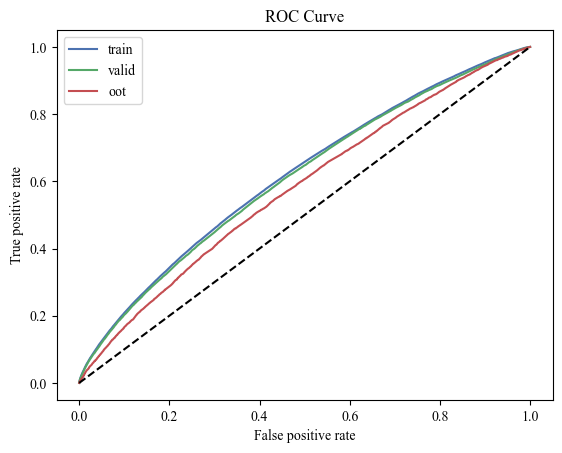

In [150]:
from ScoreCard.evaluation import ScorecardEvaluation
se = ScorecardEvaluation('信贷')
res_data = se.eval_dataset(data_end, model, keep_lst, col_name='target')

  datasets       auc  precision    recall        ks        f2        th  \
0  2024-07  0.592244   0.045917  0.400376  0.131323  0.157385  0.685178   
0  2024-08  0.601892   0.051897  0.495502  0.148007  0.182872  0.674015   
0  2024-09  0.607849   0.054861  0.580236  0.157465  0.199032  0.663866   
0  2024-10  0.625920   0.063765  0.560264  0.181518  0.219087  0.676528   
0  2024-11  0.628120   0.070576  0.513525  0.185032  0.227702  0.687779   
0  2024-12  0.614778   0.064416  0.554728  0.163741  0.219926  0.681209   
0  2025-01  0.621356   0.064779  0.587352  0.170172  0.224747  0.678644   
0  2025-02  0.610365   0.065994  0.690298  0.154146  0.238691  0.661853   
0  2025-03  0.607309   0.066281  0.792958  0.146932  0.248365  0.641345   
0  2025-04  0.598252   0.064152  0.780030  0.138659  0.241361  0.635401   
0  2025-05  0.581270   0.062543  0.678351  0.111360  0.228459  0.644244   
0  2025-06  0.575222   0.059982  0.801761  0.112922  0.230833  0.612238   

      ratio   count  
0 

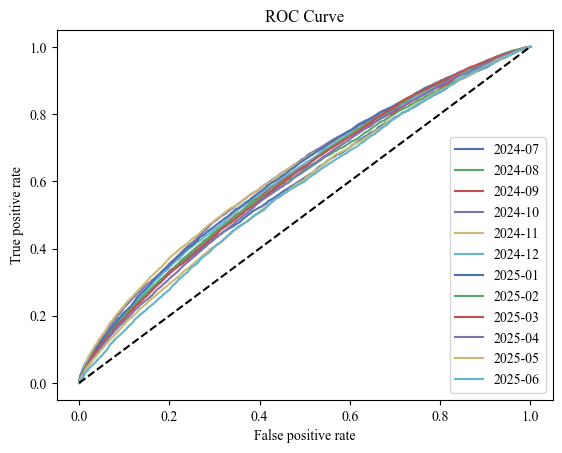

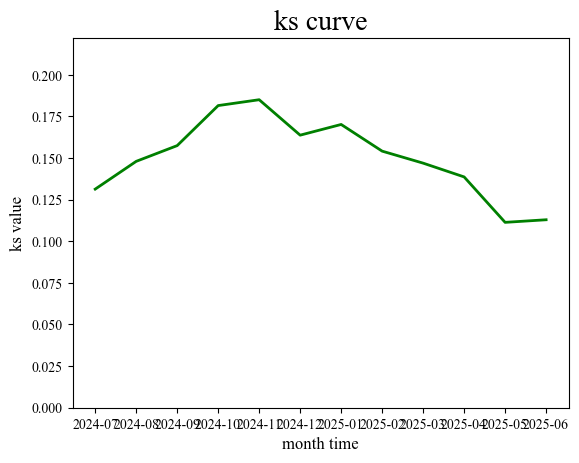

In [151]:
res_month = se.eval_month(data_end, model, keep_lst, col_name='month_time')

In [152]:
importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_})
importance.sort_values(by='importance', ascending=False)

,var_names,importance
1,theta_proba,0.422961
2,zeta_proba,0.353593
0,delta_proba,0.223446


### 分数评估

In [153]:
end_keep = list(importance[importance['importance']>0]['var_names'])
len(end_keep)

3

In [154]:
from new_tools import auto_score
# 开始分数转换
scorer = auto_score.ScoreCalculator(max_score=900, min_score=300)  # 实例化分数计算器
data_end['proba'] =  model.predict_proba(data_end[keep_lst])[:, 1]
scores, min_score, max_score, final_p, final_q, final_pdo = scorer.automatic_scoring(data_end['proba'])
data_end['score'] = scores

pdo_df = pd.DataFrame({'Min Score': min_score,
                        'Max Score': max_score,
                        'P': final_p,
                        'Q': final_q,
                        'PDO': final_pdo},index=[0])
# 打印结果
print(f"Min Score: {min_score}, Max Score: {max_score}, P: {final_p}, Q: {final_q}, PDO: {final_pdo}")

def card_score(pred, P=final_p, Q=final_q, PDO=final_pdo, good_weight=1):
    '''
    根据概率1返回卡评分
    pred:概率(array或scalar); Q:设定的Odds比率; P:比率Q时的分数
    PDO:比率为2Q时分值增加量; good_weight:好客户抽样比例
    '''
    Odds = (1-pred)*good_weight/pred
    B = -PDO/np.log(2)
    A = P + B*np.log(Q)
    score = A - B*np.log(Odds)
    # score[score<350] = 350
    # score[score>850] = 1000
    return score.astype(int)
	
data_end['score'] = card_score(data_end['proba'])

print(data_end['proba'].min(),data_end['proba'].max())
print(data_end['score'].min(),data_end['score'].max())
data_end[['score','proba']].head()

Min Score: 311, Max Score: 827, P: 800, Q: 10, PDO: 60
0.067764714 0.96575415
311 827


,score,proba
0,493,0.776036
1,493,0.776036
2,508,0.743908
3,576,0.568865
4,500,0.760153


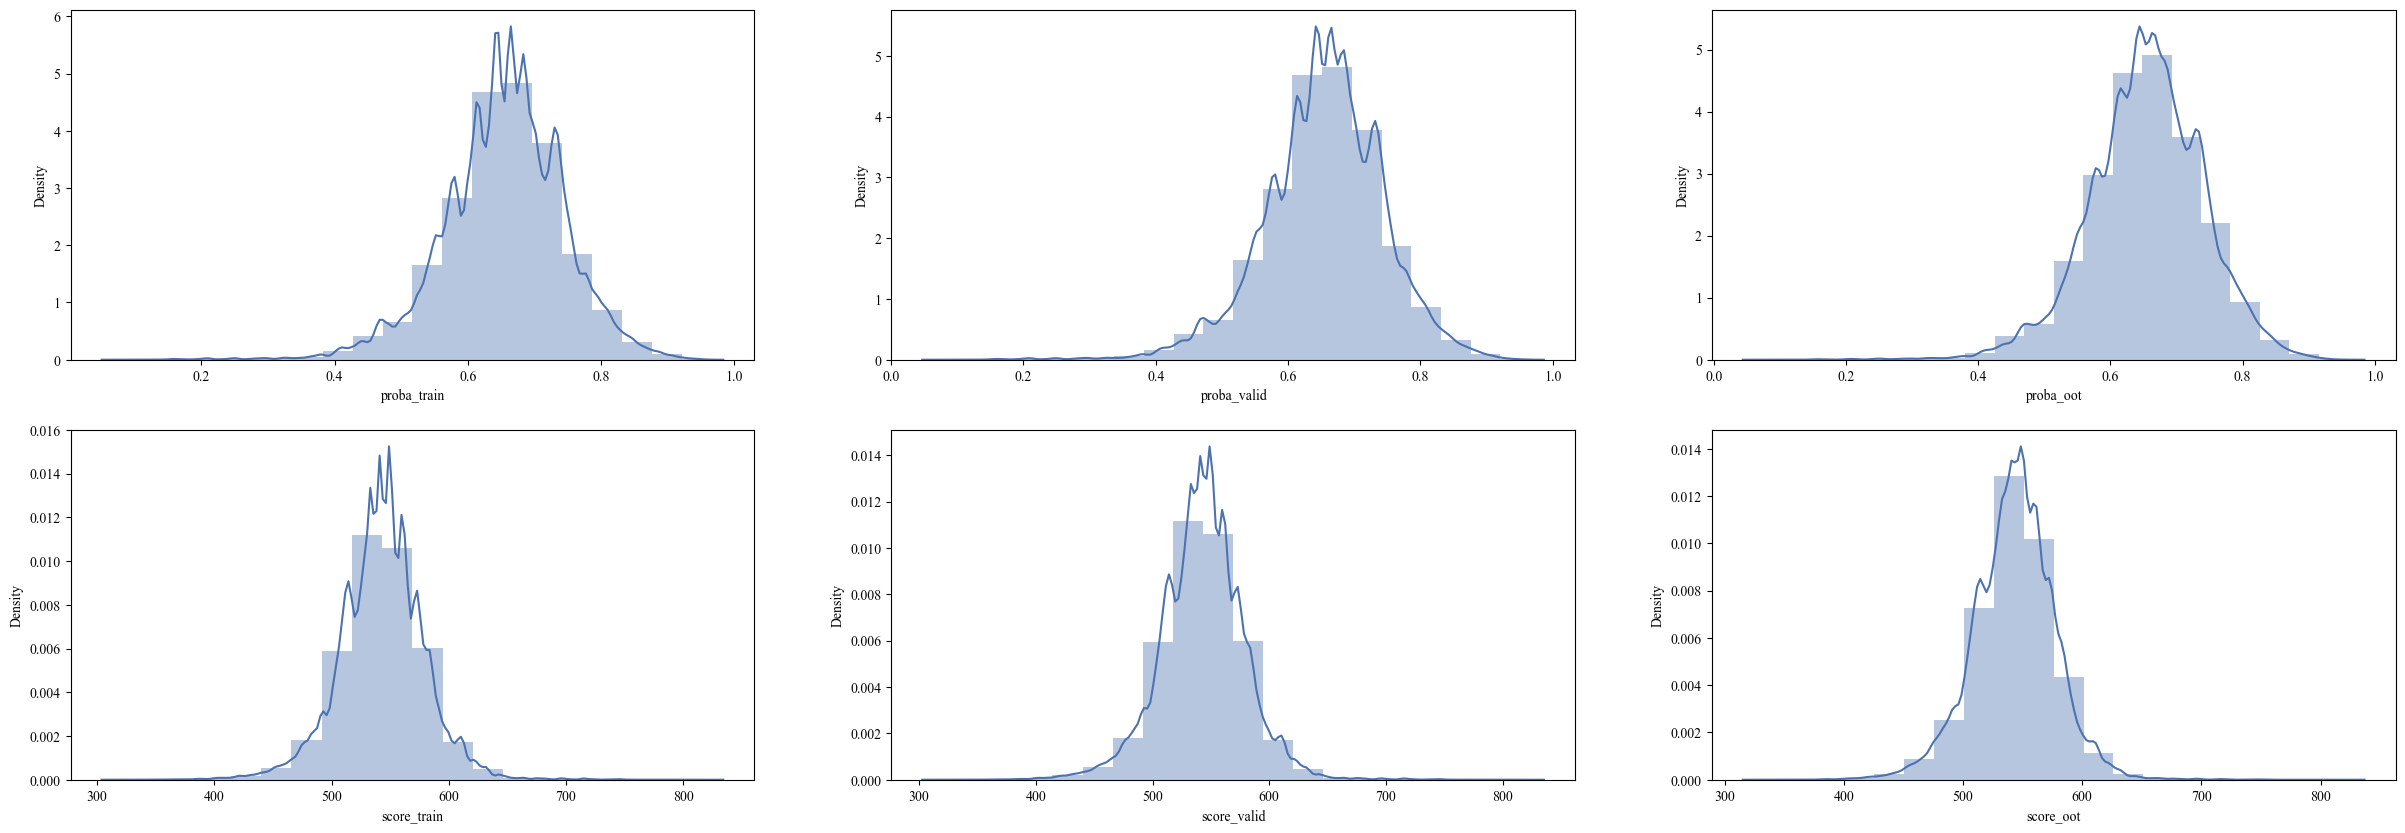

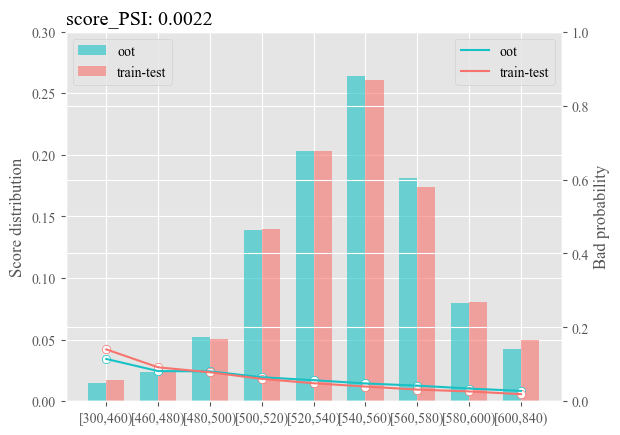

In [155]:
plt.style.use('seaborn-deep')
plt.rcParams['font.sans-serif'] = 'Times New Roman'
se.plot_distribution(data_end, bin_num=20, x_tick_break=20, col_name='target')

In [156]:
# se.plot_psi(data_end)

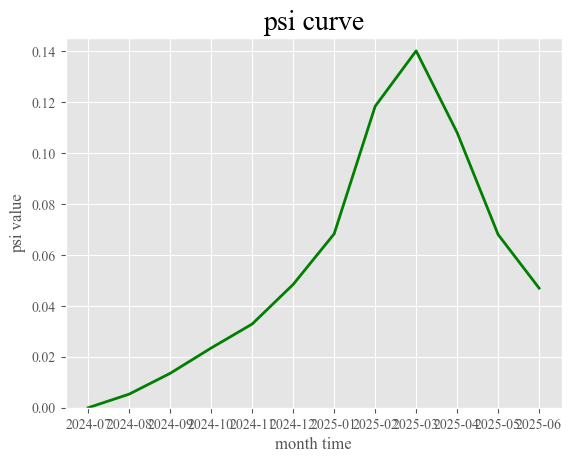

,moth,psi
0,2024-07,0.000000
1,2024-08,0.005339
2,2024-09,0.013511
3,2024-10,0.023438
4,2024-11,0.032851
5,2024-12,0.048389
6,2025-01,0.068240
7,2025-02,0.118298
8,2025-03,0.140078
9,2025-04,0.108009


In [157]:
from new_tools.new_psi import plot_month_psi_curve
plot_month_psi_curve(data_end, 'month_time')

In [158]:
import toad
score_ks =  toad.metrics.KS_bucket(data_end[data_end['target']=='train']['score'], data_end[data_end['target']=='train']['label'], 
                                   bucket=10,
#                                    q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,]
                                  )
score_ks.to_csv(FILE_PATH + 'score_ks_train.csv')
score_ks[['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','lift','cum_lift']]

,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,lift,cum_lift
0,311,500,0.093594,0.103259,0.194338,0.095535,2.034196,2.034196
1,501,515,0.061841,0.065917,0.329998,0.196469,1.344056,1.679645
2,516,526,0.054671,0.057832,0.431724,0.282080,1.188225,1.530499
3,527,534,0.048726,0.051221,0.549538,0.393329,1.059014,1.397145
4,535,542,0.043911,0.045928,0.650965,0.499605,0.954380,1.302960
5,543,549,0.039619,0.041253,0.732248,0.594001,0.861085,1.232739
6,550,559,0.037132,0.038564,0.814342,0.695725,0.807029,1.170495
7,560,569,0.033985,0.035180,0.882700,0.788270,0.738635,1.119793
8,570,583,0.028737,0.029587,0.949489,0.895207,0.624568,1.060636
9,584,827,0.022177,0.022680,1.000000,1.000000,0.482008,1.000000


In [159]:
score_ks =  toad.metrics.KS_bucket(data_end[data_end['target']=='valid']['score'], data_end[data_end['target']=='valid']['label'],
                                                                     bucket=10,
#                                    q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,]
                                  )
score_ks.to_csv(FILE_PATH + 'score_ks_valid.csv')
score_ks[['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','lift','cum_lift']]

,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,lift,cum_lift
0,311,500,0.090660,0.099699,0.190233,0.096541,1.970491,1.970491
1,501,515,0.060223,0.064082,0.322165,0.197335,1.308938,1.632585
2,516,526,0.054365,0.057490,0.423623,0.283198,1.181611,1.495853
3,527,534,0.048697,0.051190,0.541801,0.394852,1.058432,1.372162
4,535,541,0.044834,0.046938,0.617831,0.472875,0.974459,1.306542
5,542,549,0.041377,0.043163,0.726734,0.593969,0.899324,1.223521
6,550,559,0.037350,0.038799,0.809830,0.696330,0.811799,1.162998
7,560,569,0.033561,0.034727,0.877279,0.788795,0.729454,1.112176
8,570,583,0.028859,0.029717,0.944161,0.895421,0.627252,1.054432
9,584,827,0.024566,0.025185,1.000000,1.000000,0.533945,1.000000


In [160]:

score_ks =  toad.metrics.KS_bucket(data_end[data_end['target']=='oot']['score'], data_end[data_end['target']=='oot']['label'],
                                bucket=10,
#                                    q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,]
                                )
score_ks.to_csv(FILE_PATH + 'score_ks_oot.csv')
score_ks[['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','lift','cum_lift']]

,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,lift,cum_lift
0,325,501,0.084491,0.092288,0.159374,0.099536,1.601168,1.601168
1,502,515,0.065469,0.070055,0.277770,0.194963,1.240691,1.424727
2,516,526,0.063561,0.067875,0.382994,0.282321,1.204530,1.356593
3,527,535,0.055921,0.059234,0.501098,0.393765,1.059755,1.272581
4,536,542,0.050135,0.052781,0.593444,0.490961,0.950101,1.208739
5,543,550,0.047776,0.050173,0.691058,0.598775,0.905394,1.154119
6,551,559,0.048030,0.050454,0.779745,0.696211,0.910216,1.119985
7,560,569,0.042548,0.044439,0.858920,0.794403,0.806323,1.081215
8,570,582,0.041911,0.043744,0.938534,0.894641,0.794241,1.049061
9,583,827,0.030785,0.031763,1.000000,1.000000,0.583402,1.000000


In [161]:
score_ks = se.show_statistic(data_end, bin_num=10, q=None)
flag = '信贷'
show_lst = ['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','total','ks','cum_lift','通过率']
show_lst += ['通过人群整体坏账率'] if flag != '营销' else ['通过人群整体响应率']
score_ks[show_lst]

[-inf, 501.0, 516.0, 527.0, 535.0, 543.0, 550.0, 560.0, 570.0, 584.0, inf]


,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,total,ks,cum_lift,通过率,通过人群整体坏账率
0,-inf,501.0,0.091981,9.871777,0.188489,0.095688,122264.0,0.097347,1.969837,1.000000,0.046695
1,501.0,516.0,0.061780,15.186385,0.321936,0.196550,128876.0,0.131528,1.637937,0.904312,0.041903
2,516.0,527.0,0.055505,17.016423,0.423991,0.282406,109702.0,0.148520,1.501353,0.803450,0.039408
3,527.0,535.0,0.049341,19.267001,0.540812,0.392961,141261.0,0.155093,1.376248,0.717594,0.037482
4,535.0,543.0,0.044566,21.438515,0.641945,0.498925,135394.0,0.150026,1.286657,0.607039,0.035322
5,543.0,550.0,0.041068,23.349808,0.725027,0.593390,120702.0,0.138085,1.221839,0.501075,0.033367
6,550.0,560.0,0.038320,25.096196,0.809181,0.695937,131029.0,0.118791,1.162722,0.406610,0.031578
7,560.0,570.0,0.034787,27.746496,0.878536,0.789033,118953.0,0.093887,1.113434,0.304063,0.029304
8,570.0,584.0,0.030051,32.277035,0.947506,0.896203,136935.0,0.053816,1.057245,0.210967,0.026884
9,584.0,inf,0.023615,41.345466,1.000000,1.000000,132626.0,0.000000,1.000000,0.103797,0.023615


In [162]:
score_ks = se.show_statistic(data_end[data_end['target']=='oot'], bin_num=10, q=None)
flag = '信贷'
show_lst = ['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','total','ks','cum_lift','通过率']
show_lst += ['通过人群整体坏账率'] if flag != '营销' else ['通过人群整体响应率']
score_ks[show_lst]

[-inf, 502.0, 516.0, 527.0, 536.0, 543.0, 551.0, 560.0, 570.0, 583.0, inf]


,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,total,ks,cum_lift,通过率,通过人群整体坏账率
0,-inf,502.0,0.084491,10.835629,0.159374,0.099536,12889.0,0.063171,1.601168,1.000000,0.052768
1,502.0,516.0,0.065469,14.274413,0.277770,0.194963,12357.0,0.087419,1.424727,0.900464,0.049262
2,516.0,527.0,0.063561,14.732962,0.382994,0.282321,11312.0,0.106282,1.356593,0.805037,0.047340
3,527.0,536.0,0.055921,16.882280,0.501098,0.393765,14431.0,0.113312,1.272581,0.717679,0.045366
4,536.0,543.0,0.050135,18.946117,0.593444,0.490961,12586.0,0.108192,1.208739,0.606235,0.043426
5,543.0,551.0,0.047776,19.931034,0.691058,0.598775,13961.0,0.097424,1.154119,0.509039,0.042145
6,551.0,560.0,0.048030,19.820132,0.779745,0.696211,12617.0,0.088188,1.119985,0.401225,0.040631
7,560.0,570.0,0.042548,22.502773,0.858920,0.794403,12715.0,0.068111,1.081215,0.303789,0.038258
8,570.0,583.0,0.041911,22.860294,0.938534,0.894641,12980.0,0.046337,1.049061,0.205597,0.036209
9,583.0,inf,0.030785,31.483333,1.000000,1.000000,13643.0,0.000000,1.000000,0.105359,0.030785


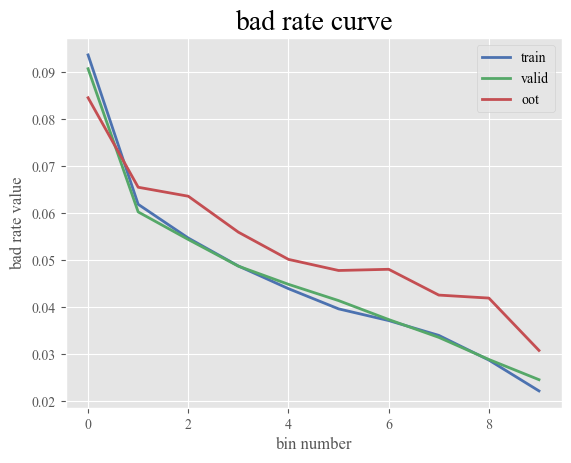

In [163]:
plt.style.use('seaborn-deep')
plt.rcParams['font.sans-serif'] = 'Times New Roman'
se.plot_badrate(data_end, bin_num=10, col_name='target')

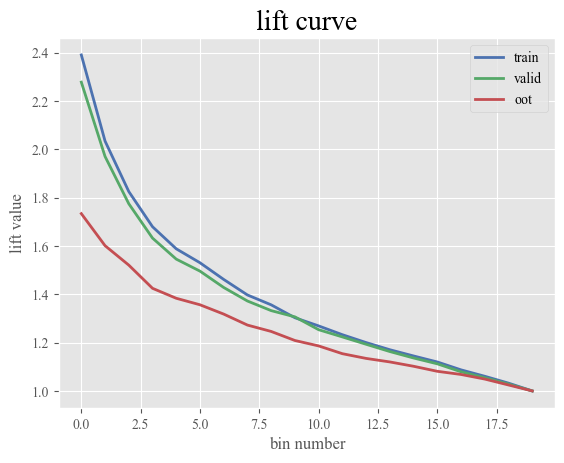

In [164]:
se.plot_lift(data_end, bin_num=20, col_name='target')

### 文件导出

In [165]:
SAVE_PATH = FILE_PATH + '上线文档/'
isExists = os.path.exists(SAVE_PATH)
if not isExists:
    os.makedirs(SAVE_PATH) 

#### 原始文件

In [166]:
data_org = data_all.copy()
data_org['backPointTime'] = pd.to_datetime(data_org['backPointTime'])
data_org1 = data_end[data_end['target'].isin(['valid', 'train'])].iloc[:1000, :][['mobile','label','backPointTime']]
data_org1.to_csv(SAVE_PATH + '原始文档.csv', index=False, encoding='utf-8-sig')

In [167]:
data_org1

,mobile,label,backPointTime
0,663c8e4d4a0d11fa9767b332f30c1921,0.0,2024-08-11
1,663c8e4d4a0d11fa9767b332f30c1921,0.0,2024-08-11
2,f3f4e2f3c61d8f1a035a0c32987714a5,0.0,2025-02-21
4,70a24bd8e0cfa4efb16a5a26b3054bc5,0.0,2025-04-28
5,7c9b40cbe1ef565aa464ccdb721f47f6,0.0,2024-12-24
...,...,...,...
1097,b7fa8227a61f8a61373a026460fe4cf5,0.0,2024-10-25
1098,d4f5da6b4a962a095084d4526083f265,0.0,2025-02-10
1099,71a8de792371fd6f5338b5d509d34c40,0.0,2025-03-02
1100,5e7df6a5feea4d327f1f756995b5a08c,0.0,2024-12-11


#### 对照文件

In [168]:
data_comp = data_end[data_end['target'].isin(['valid', 'train'])].iloc[:1000, :]
data_comp.to_csv(SAVE_PATH + '对照文档.csv', index=False, encoding='utf-8-sig')
data_comp

,delta_proba,theta_proba,zeta_proba,mobile,label,backPointTime,target,month_time,weight,qudao3_act,proba,score,bucket
0,0.672212,0.084997,0.309962,663c8e4d4a0d11fa9767b332f30c1921,0.0,2024-08-11,train,2024-08,1,信息流,0.776036,493,0
1,0.672212,0.084997,0.309962,663c8e4d4a0d11fa9767b332f30c1921,0.0,2024-08-11,train,2024-08,1,信息流,0.776036,493,0
2,0.673433,0.047374,0.426941,f3f4e2f3c61d8f1a035a0c32987714a5,0.0,2025-02-21,valid,2025-02,1,API,0.743908,508,1
4,0.634136,0.069634,0.362761,70a24bd8e0cfa4efb16a5a26b3054bc5,0.0,2025-04-28,train,2025-04,1,API,0.760153,500,0
5,0.671956,0.043136,0.309962,7c9b40cbe1ef565aa464ccdb721f47f6,0.0,2024-12-24,train,2024-12,1,API,0.581588,572,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097,0.626420,0.037783,0.309962,b7fa8227a61f8a61373a026460fe4cf5,0.0,2024-10-25,train,2024-10,1,API,0.537938,587,9
1098,0.559001,0.038428,0.286231,d4f5da6b4a962a095084d4526083f265,0.0,2025-02-10,train,2025-02,1,API,0.497186,601,9
1099,0.671956,0.030352,0.309962,71a8de792371fd6f5338b5d509d34c40,0.0,2025-03-02,train,2025-03,1,API,0.471447,610,9
1100,0.640051,0.043314,0.309962,5e7df6a5feea4d327f1f756995b5a08c,0.0,2024-12-11,valid,2024-12,1,API,0.566525,577,8


#### 模型pmml文件

In [169]:
from sklearn2pmml import sklearn2pmml, PMMLPipeline
from sklearn.pipeline import make_pipeline
# from nyoka import xgboost_to_pmml

flag = 1

if flag:
    train = data_end[data_end['target']=='train']

    pipeline = PMMLPipeline([("classifier", model)])
    pipeline.fit(train[keep_lst], train['label'])

    sklearn2pmml(pipeline, SAVE_PATH + 'xgb_model.pmml', with_repr=True)
    # xgboost_to_pmml(pipeline, keep_lst, 'label', SAVE_PATH + 'xgb_model.pmml')
else:
    model.save_model( SAVE_PATH + 'xgb_model')

In [170]:
model.save_model( SAVE_PATH + 'model.json')

In [171]:
import joblib
joblib.dump(model, SAVE_PATH + 'model.model')

['/home/zhuchen/poc/02-xyf/ronghe_all/file/上线文档/model.model']

In [172]:
pd.DataFrame({'var_names': keep_lst}).to_csv(SAVE_PATH + 'keep_lst.csv')

In [ ]:
# 建模报告输出
SAVE_PATH = FILE_PATH + '建模报告/'
isExists=os.path.exists(SAVE_PATH)
if not isExists:
    os.makedirs(SAVE_PATH) 

In [ ]:
if_single_ks = False
if_single_lift = False
if_weight = False


# 新增自动报告输出  但是这里还需要改
# 计算train和oot的psi值
from new_tools import new_psi,feature_plot_generator
from new_tools import new_psi
keep_list = keep_lst

psi_df_tv_o = new_psi.psi_for_continue_var(data_end[data_end['target'].isin(['train','valid'])]['proba'],
                                        data_end[data_end['target'].isin(['oot'])]['proba'],
                                        detail=True,method='equal_width')
psi_df_tv_o

min_month = data_end['month_time'].min()

psi_df_month = new_psi.choice_month_psi(data_end,min_month,'proba','month_time')
psi_df_month


df_list = []
temp_df = pd.DataFrame({
    'dataset':'all',
    'count':data_end['label'].count(),
    'badrate':data_end['label'].mean(),
    'badrate_weight':(data_end['label']*data_end['weight']).sum()/data_end['weight'].sum(),
    'month_min':data_end['month_time'].min(),
    'month_max':data_end['month_time'].max()
},index=[0])
df_list.append(temp_df)

def group_weight_badrate_cal(group):
    return (group['label']*group['weight']).sum()/group['weight'].sum()

for col in ['target','month_time']:
    temp_df = data_end.groupby(col).agg({'label':['count','mean'],'month_time':['min','max']}).reset_index()
    temp_df.columns = ['dataset','count','badrate','month_min','month_max']
    temp_df['badrate_weight'] = (
        data_end.groupby(col)
        .apply(group_weight_badrate_cal)  # 使用apply接收完整分组
        .reset_index(drop=True)
    )
    temp_df.sort_values(by='dataset',ascending=True,inplace=True)
    df_list.append(temp_df)
info_df = pd.concat(df_list,axis=0,ignore_index=True)

if not if_weight:
    info_df.drop(columns = ['badrate_weight'],axis=0,inplace=True)

info_df

import toad
tag_list = [['train'],['valid'],['oot']]
tag_list_str = [str(i) for i in tag_list]
df_list = []

for tag in tag_list:
    temp_df = data_end[data_end['target'].isin(tag)]
    score_ks =  toad.metrics.KS_bucket(temp_df['proba'],
                                        temp_df['label'], 
                                        bucket=10,
                                        )
    lift_df_diff = score_ks[['min','max','lift','cum_lift']]
    df_list.append(lift_df_diff)

lift_df = pd.concat(df_list,axis=1,keys=tag_list_str)
lift_df

from new_tools import iv_report

iv_calculator = iv_report.IVCalculator(data_end,label='label',target='target',keep_list=keep_list, max_leaf_nodes=6, min_samples_leaf=0.05)
iv_df = iv_calculator.iv_report(use_thread=True,max_workers=20)
iv_df.sort_values(by='train_iv',ascending=False,inplace=True)
iv_df.to_excel(SAVE_PATH + 'iv_report.xlsx',index=False)
ipt_df = pd.DataFrame({'var_name': keep_list, 'importance': model.feature_importances_})
ipt_df.sort_values(by='importance', ascending=False, inplace=True)
ipt_iv_df = pd.merge(ipt_df,iv_df,on='var_name',how='left')
ipt_iv_df.to_excel(SAVE_PATH+'ipt_iv.xlsx',index=False)

iv_detail_df = iv_calculator.detail_report(ipt_iv_df['var_name'],'all')


if if_single_ks:
    # 基于配置参数，来决定是否进行输出
    ipt_iv_df = pd.merge(ipt_iv_df,iv_detail_df[['var_name','ks']].drop_duplicates(subset=['var_name']),on='var_name',how='left')
    ipt_iv_df['ks'] = ipt_iv_df['ks'].fillna(0)
iv_detail_df.drop(columns=['ks','badCumRate','goodCumRate'],inplace=True)

if if_single_lift:
    # 基于配置参数，来决定是否进行输出
    def calc_lift(df):
        total_bad = df['bad'].sum()
        total_cnt = df['total'].sum()
        overall_bad_rate = total_bad / total_cnt
        df['lift'] = df['bad_rate'] / overall_bad_rate
        
        return df

    iv_detail_df = iv_detail_df.groupby('var_name', group_keys=False).apply(calc_lift)


import re

def extract_left(bin_str):
    """从区间字符串中提取左端点数值"""
    try:
        left = re.findall(r'[\[\(](-inf|-?\d+\.?\d*)', str(bin_str))[0]
        return float('-inf') if left == '-inf' else float(left)
    except IndexError:
        return float('inf')  # 异常值放最后

iv_detail_df = iv_detail_df.sort_values(
    by=['var_name', 'bin'],
    key=lambda s: s if s.name == 'var_name' else s.map(extract_left),
    ascending=[True, True]  # var_name升序，bin升序
)


model_performance_ks = pd.concat([res_data[['datasets','auc','ks']], res_month[['datasets','auc','ks']]])
def calc_lift(group):
    high_thr = group['score'].quantile(0.95)
    low_thr = group['score'].quantile(0.05)
    top5 = group[group['score'] >= high_thr]
    bottom5 = group[group['score'] <= low_thr]
    bad_rate_all = (group['label'] == 1).mean()
    bad_rate_top5 = (top5['label'] == 1).mean()
    bad_rate_bottom5 = (bottom5['label'] == 1).mean()
    lift_top5 = bad_rate_top5 / bad_rate_all if bad_rate_all > 0 else float('nan')
    lift_bottom5 = bad_rate_bottom5 / bad_rate_all if bad_rate_all > 0 else float('nan')
    return pd.Series({'sub_5_lift': lift_top5,'top_5_lift': lift_bottom5})

result_data = data_end.groupby('target').apply(calc_lift).reset_index()
result_month = data_end.groupby('month_time').apply(calc_lift).reset_index()
result_data.rename(columns={'target':'datasets'},inplace=True)
result_month.rename(columns={'month_time':'datasets'},inplace=True)
model_performance_lift = pd.concat([result_data,result_month])
eval_df = pd.merge(model_performance_ks,model_performance_lift,on='datasets',how='left')


with pd.ExcelWriter(SAVE_PATH + '模型评估报告.xlsx') as writer:
    info_df.to_excel(writer, sheet_name='数据概要', index=False)
    eval_df.to_excel(writer, sheet_name='模型性能', index=True)
    ipt_iv_df.to_excel(writer, sheet_name='特征重要性', index=False)
    iv_detail_df.to_excel(writer, sheet_name='特征分箱', index=False)
    lift_df.to_excel(writer, sheet_name='lift', index=True)
    psi_df_tv_o.to_excel(writer, sheet_name='psi_训练与oot', index=False)
    psi_df_month.to_excel(writer, sheet_name='psi_逐月', index=False)
    pdo_df.to_excel(writer, sheet_name='打分参数', index=False)
    feature_plot_generator.create_feature_plot_report(
        excel_writer=writer,
        data=data_end,
        feature_list=keep_lst,
        sheet_name='特征分箱报告'
    )

初始化IV计算器,获取各个数据集的索引...
初始化完成


计算在所有数据集上的IV分箱细节: 100%|██████████| 3/3 [00:00<00:00, 11.26it/s]


In [174]:
SAVE_PATH = FILE_PATH + '建模报告/'
isExists=os.path.exists(SAVE_PATH)
if not isExists:
    os.makedirs(SAVE_PATH) 

In [175]:
feature_importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_}).sort_values(by='importance', ascending=False)
key_value = pd.read_excel(FILE_PATH + 'key_value.xlsx')
key_value = key_value[key_value['var_names'].isin(keep_lst)]
result = pd.merge(feature_importance, key_value, on='var_names')
result.to_csv(SAVE_PATH + 'ipt_iv_psi.csv', index=False, encoding='utf-8-sig')

In [176]:
feature_importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_}).sort_values(by='importance', ascending=False)
feature_importance = feature_importance[feature_importance['var_names'].isin(end_keep)]
key_value = pd.read_excel(FILE_PATH + 'bins_detail.xlsx')
key_value = key_value[key_value['variable'].isin(end_keep)]
result = pd.merge(feature_importance, key_value, left_on='var_names',right_on='variable')
result.to_csv(SAVE_PATH + 'bin_details.csv', index=False, encoding='utf-8-sig')